<a href="https://colab.research.google.com/github/LoveData121/supermarket-sales-forecasting/blob/main/Sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# DATA MANIPULATION
import pandas as pd
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING MODELS
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# DEEP LEARNING
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# PREPROCESSING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# EVALUATION METRICS
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving transactions.csv to transactions.csv
Saving holidays_events.csv to holidays_events.csv
Saving oil.csv to oil.csv
Saving stores.csv to stores.csv
Saving train.csv to train.csv


In [ ]:
sales = pd.read_csv('/content/train.csv')

transactions = pd.read_csv('/content/transactions.csv')

oil = pd.read_csv('/content/oil.csv')

holidays = pd.read_csv('/content/holidays_events.csv')

stores = pd.read_csv('/content/stores.csv')

In [ ]:
# Convert ALL date columns BEFORE any operations
sales['date'] = pd.to_datetime(sales['date'])
transactions['date'] = pd.to_datetime(transactions['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

print("Dates converted successfully")

Dates converted successfully


MERGE TRANSACTIONS

In [ ]:
# Perform merges
df = sales.merge(transactions, on=['date', 'store_nbr'], how='left')
df = df.merge(oil, on='date', how='left')
df = df.merge(stores, on='store_nbr', how='left')
df = df.merge(holidays, on='date', how='left')

# Re-convert date column after merges
# Even though it was datetime before, merges can change it
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Rename the resulting type columns
df = df.rename(columns={
    'type_x': 'store_type',
    'type_y': 'holiday_type'
})

print("Renamed: 'type_x' → 'store_type', 'type_y' → 'holiday_type'")

# Verify it worked
print(f"Date column type after re-conversion: {df['date'].dtype}")
print(f"First few dates: {df['date'].head(3).tolist()}")

Renamed: 'type_x' → 'store_type', 'type_y' → 'holiday_type'
Date column type after re-conversion: datetime64[ns]
First few dates: [Timestamp('2013-01-01 00:00:00'), Timestamp('2013-01-01 00:00:00'), Timestamp('2013-01-01 00:00:00')]


VIEW MERGED DATASET

In [ ]:
display(df.sample(5, random_state=42))

,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,city,state,store_type,cluster,holiday_type,locale,locale_name,description,transferred
668753,659843,2014-01-07,23,DAIRY,471.0,0,1135.0,93.31,Ambato,Tungurahua,D,9,NaN,NaN,NaN,NaN,NaN
1267004,1250966,2014-12-05,1,BEAUTY,1.0,0,2028.0,65.89,Quito,Pichincha,D,13,Additional,Local,Quito,Fundacion de Quito-1,False
997442,981404,2014-07-06,45,HOME APPLIANCES,0.0,0,4626.0,NaN,Quito,Pichincha,A,11,NaN,NaN,NaN,NaN,NaN
873596,864686,2014-05-02,20,LAWN AND GARDEN,0.0,0,NaN,100.09,Quito,Pichincha,B,6,NaN,NaN,NaN,NaN,NaN
756145,747235,2014-02-25,25,HOME AND KITCHEN II,0.0,0,705.0,102.20,Salinas,Santa Elena,D,1,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("="*70)
print("MERGED DATASET OVERVIEW")
print("="*70)

print(f"Shape of merged dataset: {df.shape}")

print("\nFirst 5 Rows")
display(df.head())

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

MERGED DATASET OVERVIEW
Shape of merged dataset: (3054348, 17)

First 5 Rows


,id,date,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,city,state,store_type,cluster,holiday_type,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,NaN,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,NaN,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,NaN,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,NaN,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,NaN,NaN,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False



Column Names
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'transactions', 'dcoilwtico', 'city', 'state', 'store_type', 'cluster', 'holiday_type', 'locale', 'locale_name', 'description', 'transferred']

Data Types


,0
id,int64
date,datetime64[ns]
store_nbr,int64
family,object
sales,float64
onpromotion,int64
transactions,float64
dcoilwtico,float64
city,object
state,object



Missing Values


,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
transactions,249117
dcoilwtico,955152
city,0
state,0


In [ ]:
print("="*70)
print("SUMMARY OF MERGED DATASET")
print("="*70)

summary = pd.DataFrame({
    "Rows":[df.shape[0]],
    "Columns":[df.shape[1]],
    "Missing Values":[df.isnull().sum().sum()],
    "Duplicate Rows":[df.duplicated().sum()]
})

display(summary)

SUMMARY OF MERGED DATASET


,Rows,Columns,Missing Values,Duplicate Rows
0,3054348,17,13963389,0


EDA

In [ ]:
df.shape

(3054348, 17)

CHECK DATA INFORMATION

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 17 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   transactions  float64       
 7   dcoilwtico    float64       
 8   city          object        
 9   state         object        
 10  store_type    object        
 11  cluster       int64         
 12  holiday_type  object        
 13  locale        object        
 14  locale_name   object        
 15  description   object        
 16  transferred   object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(9)
memory usage: 396.1+ MB
None


SUMMARY STATISTICS

In [ ]:
df.describe()

,id,date,store_nbr,sales,onpromotion,transactions,dcoilwtico,cluster
count,3.054348e+06,3054348,3.054348e+06,3.054348e+06,3.054348e+06,2.805231e+06,2.099196e+06,3.054348e+06
mean,1.504277e+06,2015-04-26 12:11:45.717619200,2.750000e+01,3.590209e+02,2.617480e+00,1.697071e+03,6.801587e+01,8.481481e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,2.619000e+01,1.000000e+00
25%,7.546768e+05,2014-03-01 00:00:00,1.400000e+01,0.000000e+00,0.000000e+00,1.046000e+03,4.641000e+01,4.000000e+00
50%,1.507572e+06,2015-04-28 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00,1.395000e+03,5.343000e+01,8.500000e+00
75%,2.255120e+06,2016-06-22 00:00:00,4.100000e+01,1.960110e+02,0.000000e+00,2.081000e+03,9.581000e+01,1.300000e+01
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,8.359000e+03,1.106200e+02,1.700000e+01
std,8.662610e+05,NaN,1.558579e+01,1.107286e+03,1.225494e+01,9.668317e+02,2.569134e+01,4.649735e+00


In [ ]:
# Check total number of duplicate rows
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


SALES DISTRIBUTION

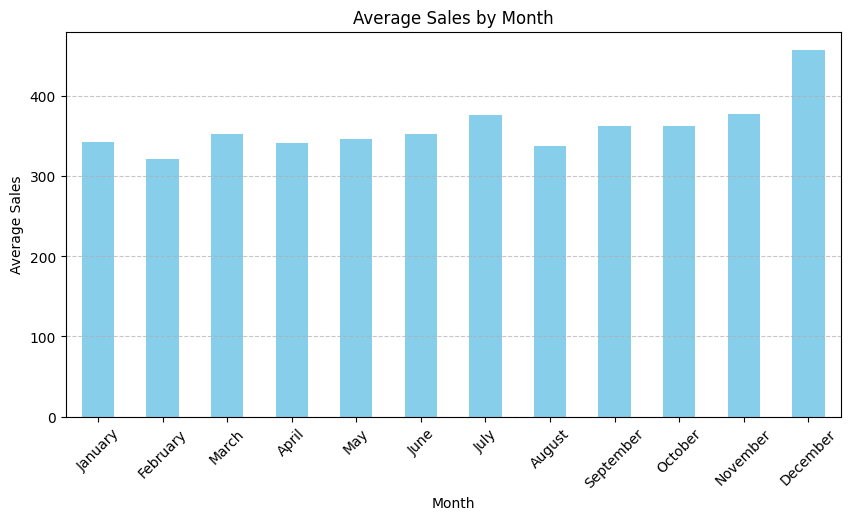

In [ ]:
import calendar

df['month_name'] = df['month'].map(lambda x: calendar.month_name[x])

month_order = list(calendar.month_name)[1:]

monthly_avg_sales = (
    df.groupby('month_name')['sales']
      .mean()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
monthly_avg_sales.plot(kind='bar', color='skyblue')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

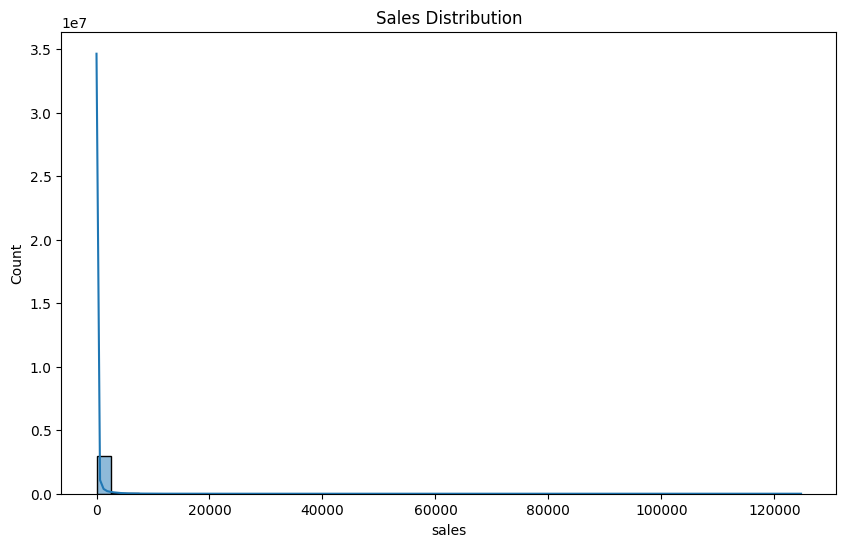

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['sales'], bins=50, kde=True)

plt.title('Sales Distribution')

plt.show()

CORRELATION HEATMAP

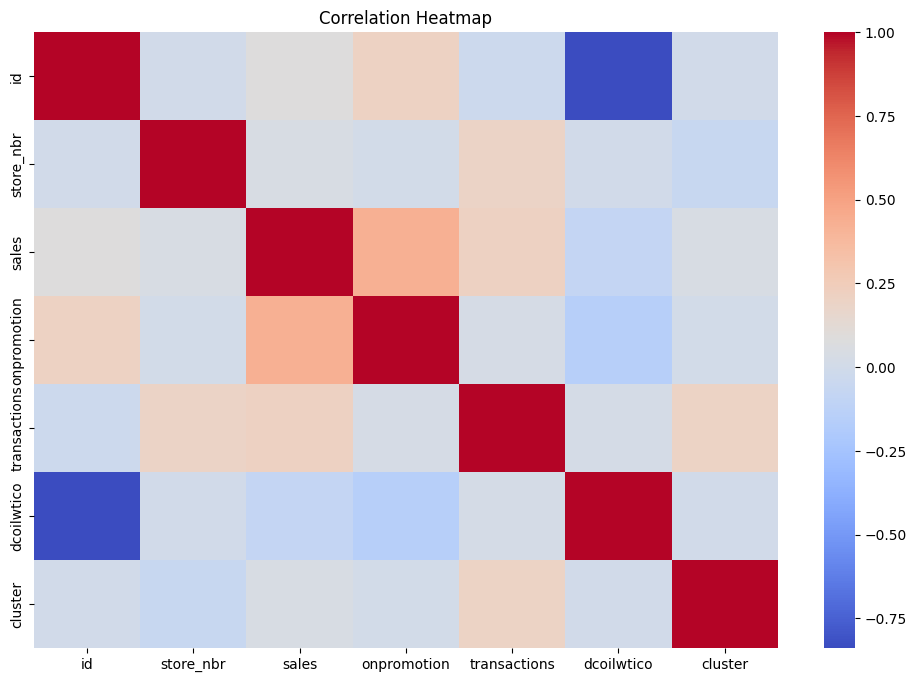

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

SALES TREND OVER TIME

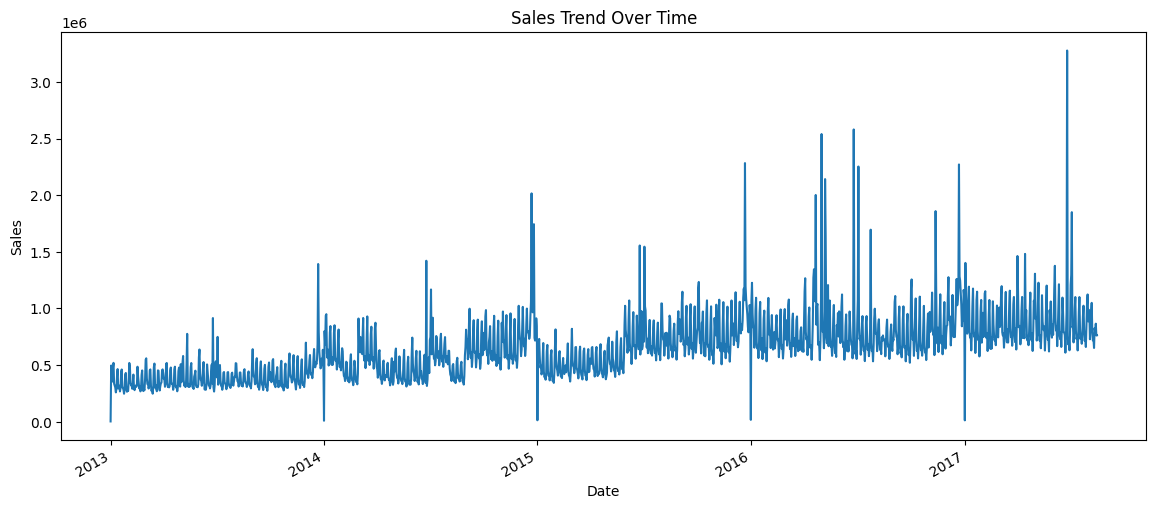

In [ ]:
sales_trend = df.groupby('date')['sales'].sum()

plt.figure(figsize=(14,6))

sales_trend.plot()

plt.title('Sales Trend Over Time')

plt.xlabel('Date')

plt.ylabel('Sales')

plt.show()

OUTLIER DETECTION

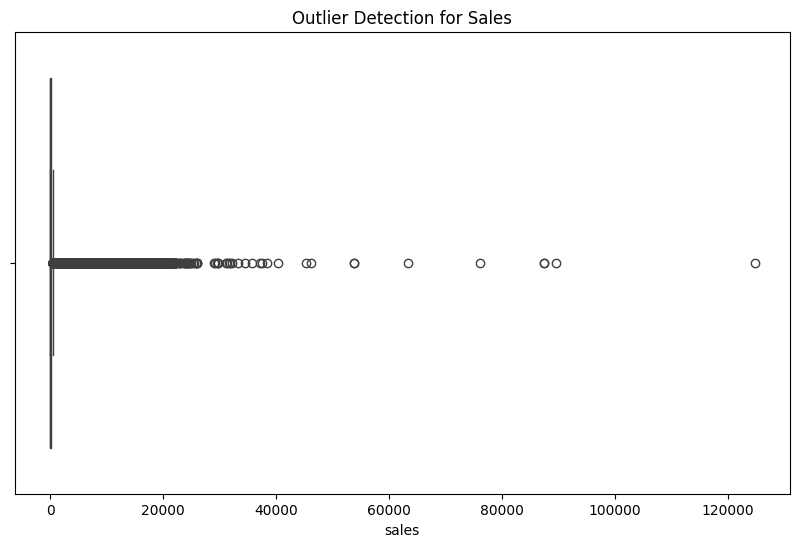

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(x=df['sales'])

plt.title('Outlier Detection for Sales')

plt.show()

IDENTIFY OUTLIERS USING IQR

In [ ]:
Q1 = df['sales'].quantile(0.25)

Q3 = df['sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['sales'] < lower_bound) |
    (df['sales'] > upper_bound)
]

print(outliers.shape)

(455506, 17)


In [ ]:
import pandas as pd
import numpy as np

def detect_outliers_iqr(data, column):
    """Return boolean mask of outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 80)
print("OUTLIER DETECTION FOR ALL NUMERIC COLUMNS")
print("=" * 80)

results = []

for col in numeric_cols:
    if df[col].dropna().empty:
        continue

    outlier_mask = detect_outliers_iqr(df, col)
    outlier_count = outlier_mask.sum()
    outlier_pct = (outlier_count / len(df)) * 100

    results.append({
        'Column': col,
        'Outliers': outlier_count,
        'Percentage': round(outlier_pct, 2),
        'Has_Outliers': outlier_count > 0
    })

    if outlier_count > 0:
        print(f"\n📊 {col}:")
        print(f"   → {outlier_count} outliers ({outlier_pct:.3f}%)")

        # Show a few outlier values
        outlier_values = df.loc[outlier_mask, col].dropna().values[:5]
        print(f"   → Sample outlier values: {outlier_values}")

# Summary
print("\n" + "=" * 80)
print("SUMMARY: Columns WITH outliers")
print("=" * 80)
outlier_cols = [r for r in results if r['Has_Outliers']]
if outlier_cols:
    for r in outlier_cols:
        print(f"✓ {r['Column']}: {r['Outliers']} outliers ({r['Percentage']}%)")
else:
    print("No outliers detected in any column by IQR method")

# Create summary DataFrame
summary_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("COMPLETE SUMMARY TABLE")
print(summary_df.to_string(index=False))

OUTLIER DETECTION FOR ALL NUMERIC COLUMNS

📊 sales:
   → 455506 outliers (14.913%)
   → Sample outlier values: [ 810.  700. 1091. 1060.  579.]

📊 onpromotion:
   → 625820 outliers (20.489%)
   → Sample outlier values: [3 5 3 1 1]

📊 transactions:
   → 154308 outliers (5.052%)
   → Sample outlier values: [4821. 4821. 4821. 4821. 4821.]

SUMMARY: Columns WITH outliers
✓ sales: 455506 outliers (14.91%)
✓ onpromotion: 625820 outliers (20.49%)
✓ transactions: 154308 outliers (5.05%)

COMPLETE SUMMARY TABLE
      Column  Outliers  Percentage  Has_Outliers
          id         0        0.00         False
   store_nbr         0        0.00         False
       sales    455506       14.91          True
 onpromotion    625820       20.49          True
transactions    154308        5.05          True
  dcoilwtico         0        0.00         False
     cluster         0        0.00         False


In [ ]:
print(df.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion',
       'transactions', 'dcoilwtico', 'city', 'state', 'store_type', 'cluster',
       'holiday_type', 'locale', 'locale_name', 'description', 'transferred'],
      dtype='object')


HANDLE MISSING VALUES

In [ ]:
# Handle missing values

# Fill missing values in transactions with the median
df['transactions'] = df['transactions'].fillna(df['transactions'].median())

# Interpolate oil prices
df['dcoilwtico'] = df['dcoilwtico'].interpolate(method='linear')
df['dcoilwtico'] = df['dcoilwtico'].bfill()
df['dcoilwtico'] = df['dcoilwtico'].fillna(df['dcoilwtico'].mean())

# Fill categorical missing values
categorical_cols = ['holiday_type', 'locale', 'locale_name', 'description']

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

# Fill missing values in transferred
df['transferred'] = df['transferred'].fillna(False)

# Check remaining missing values
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")

/tmp/ipykernel_844/3332797865.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['transferred'] = df['transferred'].fillna(False)


Missing values after cleaning: 0


In [ ]:
df.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
transactions,0
dcoilwtico,0
city,0
state,0


Extract Time Features

In [ ]:
# Extract time features - this WILL work now
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

print("Time features extracted successfully!")
print(f"Year range: {df['year'].min()} - {df['year'].max()}")

Time features extracted successfully!
Year range: 2013 - 2017


CREATING NEW FEATURES

In [ ]:
# Cyclical encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Holiday flags
df['is_holiday'] = (df['holiday_type'] != 'Unknown').astype(int)
df['is_national_holiday'] = (df['locale'] == 'National').astype(int)

# Christmas season (December)
df['is_christmas'] = (df['date'].dt.month == 12).astype(int)

# Easter season (March and April)
df['is_easter'] = (df['date'].dt.month.isin([3, 4])).astype(int)

# Ramadan season
df['is_ramadan'] = 0

# 2013
df.loc[(df['date'] >= '2013-07-01') & (df['date'] <= '2013-08-15'), 'is_ramadan'] = 1

# 2014
df.loc[(df['date'] >= '2014-06-20') & (df['date'] <= '2014-08-05'), 'is_ramadan'] = 1

# 2015
df.loc[(df['date'] >= '2015-06-10') & (df['date'] <= '2015-07-25'), 'is_ramadan'] = 1

# 2016
df.loc[(df['date'] >= '2016-06-01') & (df['date'] <= '2016-07-15'), 'is_ramadan'] = 1

# 2017
df.loc[(df['date'] >= '2017-05-20') & (df['date'] <= '2017-06-30'), 'is_ramadan'] = 1

# ============================================
# Handle transferred column properly
# ============================================

# First, check what values we have
print("Original transferred values:", df['transferred'].unique())

# Fill NaN values with False
df['transferred'] = df['transferred'].fillna(False)

# Convert any string 'Unknown' to False
df['transferred'] = df['transferred'].replace('Unknown', False)
df['transferred'] = df['transferred'].replace('unknown', False)

# Now convert to boolean then to int
# This handles both boolean True/False and string 'True'/'False'
df['is_transferred'] = df['transferred'].astype(str).apply(
    lambda x: x.lower() in ['true', '1', 't', 'yes', 'on'] if x not in ['nan', 'None', ''] else False
).astype(int)

print("Fixed transferred values:", df['transferred'].unique())
print("is_transferred values:", df['is_transferred'].unique())
print(f"Number of transferred holidays: {df['is_transferred'].sum()}")

# Sort for lag features
df = df.sort_values(['store_nbr', 'family', 'date'])

# Lag features
for lag in [7, 14, 21]:
    df[f'sales_lag_{lag}'] = df.groupby(['store_nbr', 'family'])['sales'].shift(lag)

# Rolling averages
for window in [7, 14]:
    df[f'sales_ma_{window}'] = df.groupby(['store_nbr', 'family'])['sales'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    df[f'sales_std_{window}'] = df.groupby(['store_nbr', 'family'])['sales'].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )

# Fill NaN values from lag features
df = df.fillna(0)

# Price feature
df['onpromotion_ratio'] = df['onpromotion'] / (df['onpromotion'] + 1)

print("All features created successfully!")
print(f"Final shape: {df.shape}")

Original transferred values: [False  True]
Fixed transferred values: [False  True]
is_transferred values: [0 1]
Number of transferred holidays: 16038
All features created successfully!
Final shape: (3054348, 40)


ENCODING CATEGORICAL VAVLUES

In [ ]:
# Encode categorical variables
categorical_features = [
    'family',
    'city',
    'state',
    'store_type',
    'holiday_type',
    'locale',
    'locale_name'
]

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# Drop original date column and unnecessary columns
columns_to_drop = ['date', 'description']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(existing_cols_to_drop, axis=1)

print(f"Final feature count: {len(df.columns)}")

Encoded family: 33 unique values
Encoded city: 22 unique values
Encoded state: 16 unique values
Encoded store_type: 5 unique values
Encoded holiday_type: 7 unique values
Encoded locale: 4 unique values
Encoded locale_name: 25 unique values
Final feature count: 38


Log Transformation to Sales

In [ ]:
# Apply log transformation to handle outliers
df['sales_log'] = np.log1p(df['sales'])

print(f"Sales range before log: {df['sales'].min():.2f} - {df['sales'].max():.2f}")
print(f"Sales range after log: {df['sales_log'].min():.2f} - {df['sales_log'].max():.2f}")

Sales range before log: 0.00 - 124717.00
Sales range after log: 0.00 - 11.73


CLEANED DATASET

In [ ]:
print("="*60)
print("FINAL CLEANED DATASET")
print("="*60)

print("Shape:", df.shape)

display(df.head())

display(df.tail())

df.info()

print(df.isnull().sum())

display(df.describe())

FINAL CLEANED DATASET
Shape: (3054348, 39)


,id,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,city,state,store_type,...,is_transferred,sales_lag_7,sales_lag_14,sales_lag_21,sales_ma_7,sales_std_7,sales_ma_14,sales_std_14,onpromotion_ratio,sales_log
0,0,1,0,0.0,0,1395.0,93.140000,18,12,3,...,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
1782,1782,1,0,2.0,0,2111.0,93.140000,18,12,3,...,0,0.0,0.0,0.0,1.000000,1.414214,1.000000,1.414214,0.0,1.098612
3564,3564,1,0,3.0,0,1833.0,92.970000,18,12,3,...,0,0.0,0.0,0.0,1.666667,1.527525,1.666667,1.527525,0.0,1.386294
5346,5346,1,0,3.0,0,1863.0,93.120000,18,12,3,...,0,0.0,0.0,0.0,2.000000,1.414214,2.000000,1.414214,0.0,1.386294
7128,7128,1,0,5.0,0,1509.0,93.120022,18,12,3,...,0,0.0,0.0,0.0,2.600000,1.816590,2.600000,1.816590,0.0,1.791759


,id,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,city,state,store_type,...,is_transferred,sales_lag_7,sales_lag_14,sales_lag_21,sales_ma_7,sales_std_7,sales_ma_14,sales_std_14,onpromotion_ratio,sales_log
3047087,2993627,54,32,0.0,0,768.0,48.810000,5,10,2,...,0,0.0,4.0,0.0,3.000000,4.281744,3.142857,3.109715,0.0,0.000000
3048869,2995409,54,32,1.0,1,903.0,48.245344,5,10,2,...,0,3.0,4.0,3.0,2.714286,4.347961,2.928571,3.149219,0.5,0.693147
3050651,2997191,54,32,2.0,0,1054.0,47.635515,5,10,2,...,0,0.0,4.0,5.0,3.000000,4.203173,2.785714,3.142233,0.0,1.098612
3052433,2998973,54,32,0.0,0,818.0,47.590000,5,10,2,...,0,0.0,4.0,1.0,3.000000,4.203173,2.500000,3.204564,0.0,0.000000
3054215,3000755,54,32,3.0,0,802.0,47.570000,5,10,2,...,0,12.0,3.0,7.0,1.714286,1.496026,2.500000,3.204564,0.0,1.386294


<class 'pandas.core.frame.DataFrame'>
Index: 3054348 entries, 0 to 3054215
Data columns (total 39 columns):
 #   Column               Dtype  
---  ------               -----  
 0   id                   int64  
 1   store_nbr            int64  
 2   family               int64  
 3   sales                float64
 4   onpromotion          int64  
 5   transactions         float64
 6   dcoilwtico           float64
 7   city                 int64  
 8   state                int64  
 9   store_type           int64  
 10  cluster              int64  
 11  holiday_type         int64  
 12  locale               int64  
 13  locale_name          int64  
 14  transferred          bool   
 15  year                 int32  
 16  month                int32  
 17  day                  int32  
 18  day_of_week          int32  
 19  quarter              int32  
 20  month_sin            float64
 21  month_cos            float64
 22  day_of_week_sin      float64
 23  day_of_week_cos      float64
 24  is_

,id,store_nbr,family,sales,onpromotion,transactions,dcoilwtico,city,state,store_type,...,is_transferred,sales_lag_7,sales_lag_14,sales_lag_21,sales_ma_7,sales_std_7,sales_ma_14,sales_std_14,onpromotion_ratio,sales_log
count,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,...,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06
mean,1.504277e+06,2.750000e+01,1.600000e+01,3.590209e+02,2.617480e+00,1.672434e+03,6.782461e+01,1.255556e+01,8.796296e+00,2.000000e+00,...,5.250875e-03,3.572550e+02,3.552738e+02,3.532223e+02,3.584521e+02,1.057175e+02,3.579226e+02,1.095535e+02,1.537881e-01,2.930228e+00
std,8.662610e+05,1.558579e+01,9.521906e+00,1.107286e+03,1.225494e+01,9.302462e+02,2.568140e+01,6.264737e+00,4.165021e+00,1.201851e+00,...,7.227244e-02,1.105085e+03,1.102125e+03,1.098850e+03,1.051933e+03,3.556130e+02,1.045094e+03,3.585555e+02,3.142480e-01,2.695540e+00
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,2.619000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,7.546768e+05,1.400000e+01,8.000000e+00,0.000000e+00,0.000000e+00,1.084000e+03,4.632000e+01,8.000000e+00,6.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.428571e-01,3.631365e-01,0.000000e+00,0.000000e+00
50%,1.507572e+06,2.750000e+01,1.600000e+01,1.100000e+01,0.000000e+00,1.395000e+03,5.329665e+01,1.400000e+01,1.000000e+01,2.000000e+00,...,0.000000e+00,1.094450e+01,1.000000e+01,1.000000e+01,1.214286e+01,6.047432e+00,1.221429e+01,6.546956e+00,0.000000e+00,2.484907e+00
75%,2.255120e+06,4.100000e+01,2.400000e+01,1.960110e+02,0.000000e+00,1.980000e+03,9.576844e+01,1.800000e+01,1.200000e+01,3.000000e+00,...,0.000000e+00,1.942720e+02,1.923940e+02,1.903613e+02,2.031429e+02,6.109347e+01,2.040476e+02,6.434206e+01,0.000000e+00,5.283260e+00
max,3.000887e+06,5.400000e+01,3.200000e+01,1.247170e+05,7.410000e+02,8.359000e+03,1.106200e+02,2.100000e+01,1.500000e+01,4.000000e+00,...,1.000000e+00,1.247170e+05,1.247170e+05,1.247170e+05,3.446543e+04,4.609861e+04,2.261543e+04,3.498071e+04,9.986523e-01,1.173381e+01


Features and Target

In [ ]:
# features and target
feature_cols = [col for col in df.columns if col not in ['sales', 'sales_log', 'id']]
X = df[feature_cols]
y = df['sales_log']  # Use log-transformed target
y_original = df['sales']

print(f"Features: {len(feature_cols)}")
print(f"Sample of features: {feature_cols[:10]}")

Features: 36
Sample of features: ['store_nbr', 'family', 'onpromotion', 'transactions', 'dcoilwtico', 'city', 'state', 'store_type', 'cluster', 'holiday_type']


Time-Based Train-Test Split

In [ ]:
# Sort by time to maintain temporal order
df_sorted = df.sort_values(['year', 'month', 'day']).reset_index(drop=True)
X_sorted = df_sorted[feature_cols]
y_sorted = df_sorted['sales_log']

# Use last 20% as test set (most recent data)
split_idx = int(len(X_sorted) * 0.8)

X_train = X_sorted[:split_idx]
y_train = y_sorted[:split_idx]
X_test = X_sorted[split_idx:]
y_test = y_sorted[split_idx:]

print(f"Training set size: {len(X_train)} ({split_idx/len(X_sorted)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} ({(1-split_idx/len(X_sorted))*100:.1f}%)")

Training set size: 2443478 (80.0%)
Testing set size: 610870 (20.0%)


HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import time
import numpy as np

print("=" * 60)
print("FAST HYPERPARAMETER TUNING (Randomized Search)")
print("=" * 60)

# ============================================
# Use smaller sample for faster tuning
# ============================================
print("\n📊 Creating sample for fast tuning...")
tune_sample_size = 50000  # Use 50k samples for tuning
X_tune_sample = X_train.sample(n=tune_sample_size, random_state=42)
y_tune_sample = y_train.loc[X_tune_sample.index]
print(f"✅ Using {tune_sample_size:,} samples for tuning")

# ============================================
# RANDOM FOREST TUNING
# ============================================
print("\n🔍 Tuning Random Forest...")

rf_param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=15,  # Test 15 random combinations
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_rf = time.time()
rf_random.fit(X_tune_sample, y_tune_sample)
rf_time = time.time() - start_rf

print(f"\n✅ RF Tuning completed in {rf_time:.1f}s")
print(f"✅ Best RF Parameters: {rf_random.best_params_}")
print(f"✅ Best RF MAE: {-rf_random.best_score_:.2f}")

# ============================================
# XGBOOST TUNING
# ============================================
print("\n🔍 Tuning XGBoost...")

xgb_param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_random = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_param_dist,
    n_iter=15,  # Test 15 random combinations
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start_xgb = time.time()
xgb_random.fit(X_tune_sample, y_tune_sample)
xgb_time = time.time() - start_xgb

print(f"\n✅ XGB Tuning completed in {xgb_time:.1f}s")
print(f"✅ Best XGB Parameters: {xgb_random.best_params_}")
print(f"✅ Best XGB MAE: {-xgb_random.best_score_:.2f}")

# ============================================
# SAVE BEST PARAMETERS FOR YOUR TRAINING CODE
# ============================================
print("\n" + "=" * 60)
print("BEST PARAMETERS FOUND - USE THESE IN YOUR TRAINING CODE")
print("=" * 60)

print(f"\n🔹 Random Forest Best Params:")
print(f"   {rf_random.best_params_}")

print(f"\n🔹 XGBoost Best Params:")
print(f"   {xgb_random.best_params_}")

# Optionally, you can save the best parameters to a file
import json
with open('best_params.json', 'w') as f:
    json.dump({
        'random_forest': rf_random.best_params_,
        'xgboost': xgb_random.best_params_
    }, f, indent=2)
print("\n✅ Best parameters saved to 'best_params.json'")

FAST HYPERPARAMETER TUNING (Randomized Search)

📊 Creating sample for fast tuning...
✅ Using 50,000 samples for tuning

🔍 Tuning Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ RF Tuning completed in 693.4s
✅ Best RF Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
✅ Best RF MAE: 0.22

🔍 Tuning XGBoost...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

✅ XGB Tuning completed in 93.7s
✅ Best XGB Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 1.0}
✅ Best XGB MAE: 0.21

BEST PARAMETERS FOUND - USE THESE IN YOUR TRAINING CODE

🔹 Random Forest Best Params:
   {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}

🔹 XGBoost Best Params:
   {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree':

MODEL DEVELOPMENT

Train Model

In [ ]:
# ============================================
# TRAIN MODELS WITH TUNED PARAMETERS
# ============================================

# Random Forest with best parameters from tuning
print("Training Random Forest with optimized parameters...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=None,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("✅ Random Forest training complete")

# XGBoost with best parameters from tuning
print("Training XGBoost with optimized parameters...")
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
print("✅ XGBoost training complete")

Training Random Forest with optimized parameters...
✅ Random Forest training complete
Training XGBoost with optimized parameters...
✅ XGBoost training complete


Evaluate Models

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predict
rf_pred_log = rf_model.predict(X_test)
xgb_pred_log = xgb_model.predict(X_test)

# Convert back to original scale
rf_pred = np.expm1(rf_pred_log)
xgb_pred = np.expm1(xgb_pred_log)
y_test_original = np.expm1(y_test)

# Save metrics
rf_r2 = r2_score(y_test_original, rf_pred)
rf_mae = mean_absolute_error(y_test_original, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_original, rf_pred))

xgb_r2 = r2_score(y_test_original, xgb_pred)
xgb_mae = mean_absolute_error(y_test_original, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test_original, xgb_pred))

# Print results
print("=" * 60)
print("MODEL EVALUATION RESULTS")
print("=" * 60)

print("\nRandom Forest")
print(f"R² Score : {rf_r2:.4f}")
print(f"MAE      : ${rf_mae:.2f}")
print(f"RMSE     : ${rf_rmse:.2f}")

print("\nXGBoost")
print(f"R² Score : {xgb_r2:.4f}")
print(f"MAE      : ${xgb_mae:.2f}")
print(f"RMSE     : ${xgb_rmse:.2f}")

MODEL EVALUATION RESULTS

Random Forest
R² Score : 0.9598
MAE      : $58.55
RMSE     : $273.66

XGBoost
R² Score : 0.9354
MAE      : $74.36
RMSE     : $346.87


COMPARISON TABLE

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "R²": [rf_r2, xgb_r2],
    "MAE": [rf_mae, xgb_mae],
    "RMSE": [rf_rmse, xgb_rmse]
})

comparison = comparison.round(2)

comparison

,Model,R²,MAE,RMSE
0,Random Forest,0.96,58.55,273.66
1,XGBoost,0.94,74.36,346.87


VISUALIZATION Results

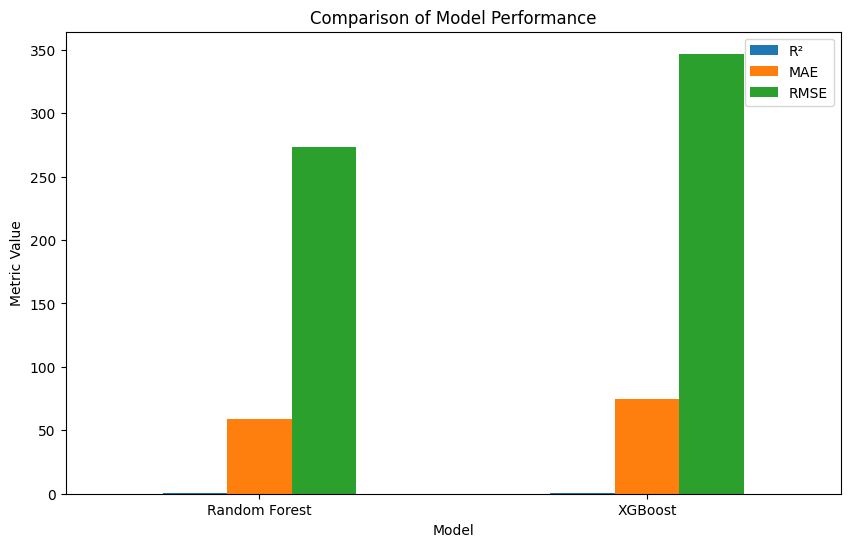

In [ ]:
comparison.plot(
    x="Model",
    figsize=(10,6),
    kind="bar"
)

plt.title("Comparison of Model Performance")

plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.show()

Random Forest

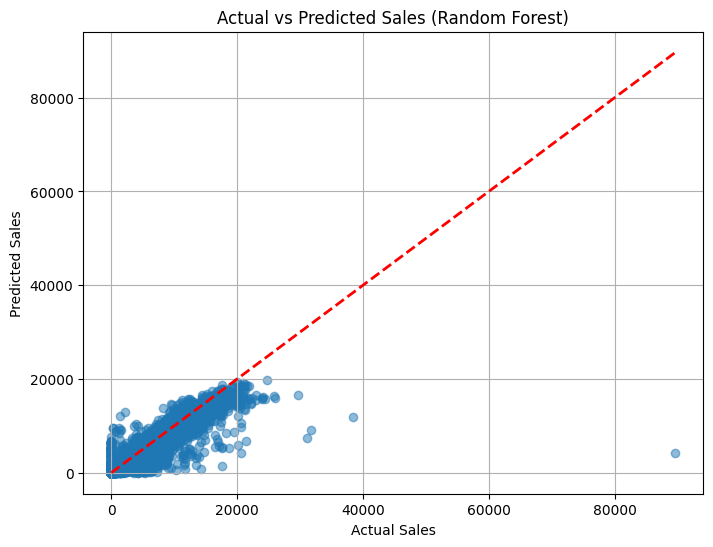

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_original,
    rf_pred,
    alpha=0.5
)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")

plt.grid(True)
plt.show()

XGBoost

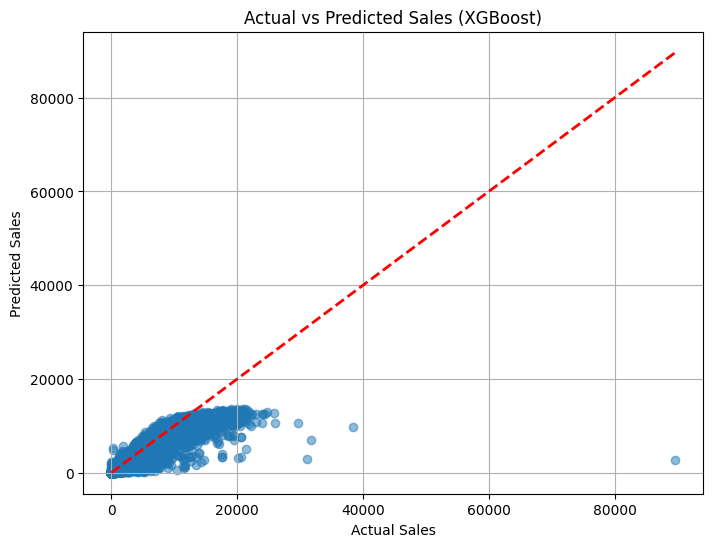

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test_original,
    xgb_pred,
    alpha=0.5
)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (XGBoost)")

plt.grid(True)
plt.show()

Random Forest Residual Plot


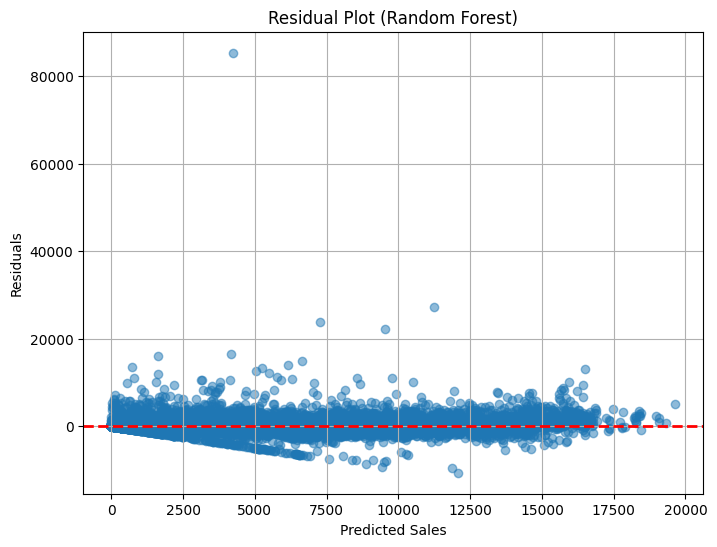

In [ ]:
import matplotlib.pyplot as plt

# Calculate residuals
rf_residuals = y_test_original - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(
    rf_pred,
    rf_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")

plt.grid(True)

plt.show()

XGBoost Residual Plot

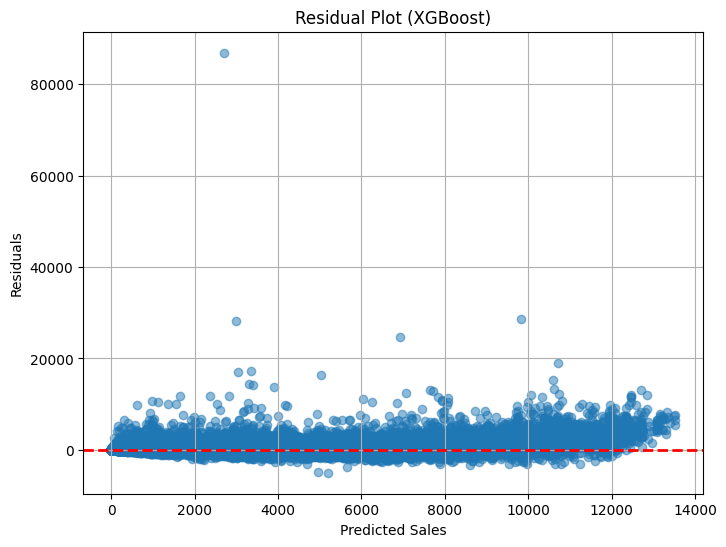

In [ ]:
# Calculate residuals
xgb_residuals = y_test_original - xgb_pred

plt.figure(figsize=(8,6))

plt.scatter(
    xgb_pred,
    xgb_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)")

plt.grid(True)

plt.show()

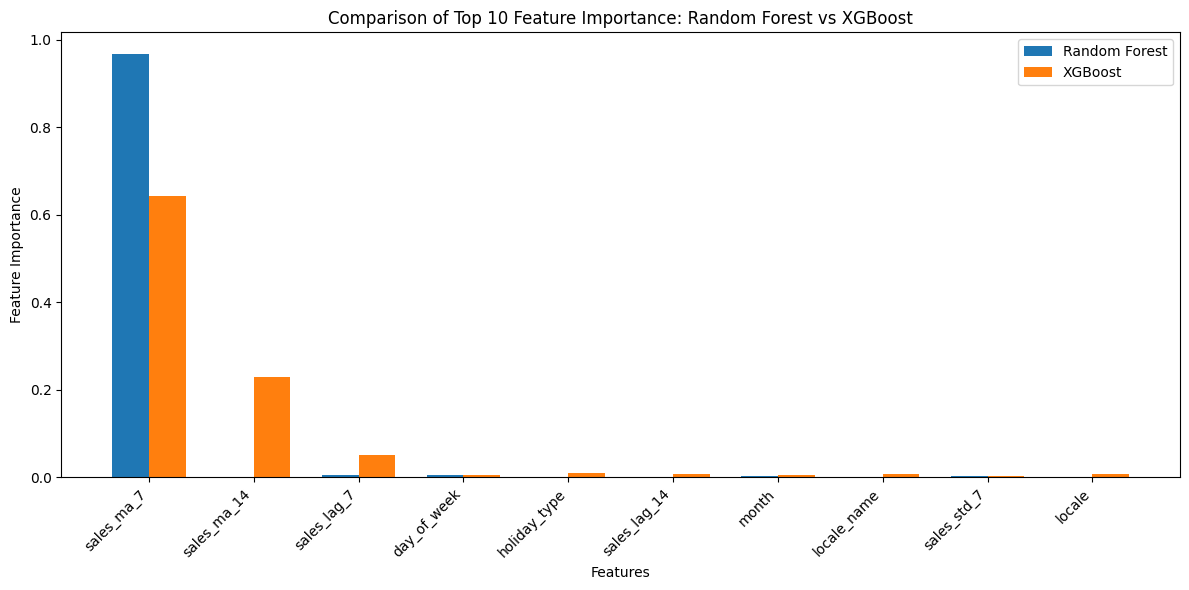

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance DataFrames
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Random Forest': rf_model.feature_importances_
})

xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'XGBoost': xgb_model.feature_importances_
})

# Merge the two DataFrames
comparison = rf_importance.merge(xgb_importance, on='Feature')

# Calculate average importance across both models
comparison['Average'] = (comparison['Random Forest'] + comparison['XGBoost']) / 2

# Select the Top 10 features based on average importance
comparison = comparison.sort_values('Average', ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))

x = range(len(comparison))
width = 0.35

plt.bar([i - width/2 for i in x],
        comparison['Random Forest'],
        width=width,
        label='Random Forest')

plt.bar([i + width/2 for i in x],
        comparison['XGBoost'],
        width=width,
        label='XGBoost')

plt.xticks(x, comparison['Feature'], rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Feature Importance')
plt.title('Comparison of Top 10 Feature Importance: Random Forest vs XGBoost')
plt.legend()

plt.tight_layout()
plt.show()